In [26]:
# Cell 1: Import libraries for data management, geographic maths, and mapping
import pandas as pd
import geopy.distance
import folium
import numpy as np

print("Tools successfully loaded for the Liebherr Network Analysis.")

Tools successfully loaded for the Liebherr Network Analysis.


In [27]:
# Cell 2: Load supply and demand data from the 'data' folder
# We use relative paths to ensure the notebook works on any machine
supply_df = pd.read_csv('../data/supply_hubs.csv')
demand_df = pd.read_csv('../data/demand_regions.csv')

print("Data successfully loaded from CSV files.")

Data successfully loaded from CSV files.


In [28]:
# Cell 3: Preview the first few rows of the dataframes to verify accuracy
print("--- Current Supply Hubs (Liebherr Branches) ---")
display(supply_df.head())

print("\n--- Mining Customer Regions (Demand Centers) ---")
display(demand_df.head())

--- Current Supply Hubs (Liebherr Branches) ---


,Location,Latitude,Longitude,Role
0,Perth (Redcliffe),-31.92,115.96,Primary Western Hub
1,Adelaide (Cavan),-34.82,138.64,National Reman Centre
2,Sydney (Erskine Park),-33.80,150.80,Distribution Centre
3,Brisbane (Yatala),-27.75,153.23,Sales & Support Hub
4,Mackay (Paget),-21.18,149.18,Bowen Basin Gateway



--- Mining Customer Regions (Demand Centers) ---


,Region,Latitude,Longitude,Primary_Commodity
0,Pilbara,-21.75,118.50,Iron Ore
1,Bowen Basin,-22.50,148.50,Coal
2,Hunter Valley,-32.50,151.00,Coal
3,WA Goldfields,-30.75,121.50,Gold / Nickel
4,Olympic Dam,-30.43,136.88,Copper / Uranium


In [29]:
# Cell 4
# Note: Initialise the base map of Australia.
# We center the map at a central latitude/longitude and set a zoom level
# that allows us to see every state and territory.

map_baseline = folium.Map(location=[-25.27, 133.77], zoom_start=4)

print("Base map of Australia initialised.")

Base map of Australia initialised.


In [30]:
# Cell 5
# Note: Adding the nodes to our map. 
# We loop through the 'supply_df' for blue pins and 'demand_df' for red pins.
# This visualises the starting 'Supply Hubs' and the 'Demand Centres' where the machines are.

# 1. Plot Supply Hubs (Existing Liebherr Network)
for idx, row in supply_df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Supply: {row['Location']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(map_baseline)

# 2. Plot Demand Regions (Mining Customers)
for idx, row in demand_df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Demand: {row['Region']} ({row['Primary_Commodity']})",
        icon=folium.Icon(color='red', icon='warning-sign')
    ).add_to(map_baseline)

# Display the map in the notebook
map_baseline

In [31]:
# Cell 6
# Note: Deep Infrastructure Routing & Alternative Path Extraction.
# 1. We ping OSRM requesting multiple paths (alternatives=true) and road data (steps=true).
# 2. We extract the specific highways/towns driven through for EACH alternative.
# 3. We save this massive, highly detailed infrastructure map to CSV.
# 4. We formally apply Dijkstra's to select the mathematically optimal route.

import requests
import time
import numpy as np
import pandas as pd
import networkx as nx

def get_detailed_routes(lat1, lon1, lat2, lon2):
    """
    Fetches multiple route options from OSRM including turn-by-turn road names.
    """
    # Notice the added parameters: alternatives=true and steps=true
    url = f"http://router.project-osrm.org/route/v1/driving/{lon1},{lat1};{lon2},{lat2}?alternatives=true&steps=true&overview=false"
    
    routes_data = []
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('code') == 'Ok':
                # Loop through every alternative route OSRM found for this A-to-B pair
                for i, route in enumerate(data['routes']):
                    distance_km = route['distance'] / 1000.0
                    
                    # Extract the road names/waypoints from the routing steps
                    steps = route['legs'][0]['steps']
                    roads = []
                    for step in steps:
                        road_name = step.get('name', '')
                        # Add road to our list if it has a name and isn't a duplicate of the last step
                        if road_name and (len(roads) == 0 or roads[-1] != road_name):
                            roads.append(road_name)
                            
                    # Join the roads into a readable path sequence
                    path_description = " -> ".join(roads) if roads else "Direct / Unnamed Local Road"
                    
                    routes_data.append({
                        'Route_Option': f"Option {i + 1}",
                        'Distance_km': distance_km,
                        'Waypoints_and_Highways': path_description
                    })
    except requests.exceptions.RequestException:
        pass
    
    return routes_data

print("Phase 1: Deep Scanning Australian Road Infrastructure (Fetching Alternatives)...")

hubs = supply_df['Location'].tolist()
mines = demand_df['Region'].tolist()

# ---------------------------------------------------------
# PHASE 1.5: BUILD THE HIGH-RESOLUTION ROUTING DATABASE
# ---------------------------------------------------------
all_detailed_routes = []

for _, demand_row in demand_df.iterrows():
    for _, supply_row in supply_df.iterrows():
        # Get all route options between this specific Hub and Mine
        options = get_detailed_routes(
            demand_row['Latitude'], demand_row['Longitude'],
            supply_row['Latitude'], supply_row['Longitude']
        )
        
        for opt in options:
            all_detailed_routes.append({
                'Demand_Region': demand_row['Region'],
                'Supply_Hub': supply_row['Location'],
                'Route_Option': opt['Route_Option'],
                'Distance_km': opt['Distance_km'],
                'Waypoints_and_Highways': opt['Waypoints_and_Highways']
            })
            
        time.sleep(0.2) # API Rate Limiting

# Convert to DataFrame and sort by Region, Hub, and Route Option
detailed_routes_df = pd.DataFrame(all_detailed_routes)
detailed_routes_df = detailed_routes_df.sort_values(by=['Demand_Region', 'Supply_Hub', 'Distance_km'])

print("\n--- Phase 1 Output: Exhaustive Infrastructure Routes ---")
# Show a preview of the detailed waypoints
display(detailed_routes_df[['Demand_Region', 'Supply_Hub', 'Route_Option', 'Distance_km', 'Waypoints_and_Highways']].head(10).round(2))

# Save this highly granular data to CSV
detailed_routes_df.to_csv('../data/all_possible_routes_with_waypoints.csv', index=False)
print(f"\n✅ Audit file successfully saved to: data/all_possible_routes_with_waypoints.csv")


# ---------------------------------------------------------
# PHASE 2: DIJKSTRA'S SHORTEST PATH EVALUATION
# ---------------------------------------------------------
print("\nPhase 2: Applying Dijkstra's Algorithm to select the optimal logistical paths...")
G = nx.DiGraph()

# Feed ALL our options into the Network Graph. 
# NetworkX automatically keeps the edge with the lowest weight (shortest distance) 
# when multiple edges are added between the same two nodes.
for _, route in detailed_routes_df.iterrows():
    # Only add to graph if the edge doesn't exist OR if this route is shorter than the existing one
    if not G.has_edge(route['Supply_Hub'], route['Demand_Region']) or \
       route['Distance_km'] < G[route['Supply_Hub']][route['Demand_Region']]['weight']:
        G.add_edge(route['Supply_Hub'], route['Demand_Region'], weight=route['Distance_km'])

optimal_routes = []
for mine in mines:
    shortest_distance = float('inf')
    best_hub = None
    
    # Check Dijkstra path length from every hub to this specific mine
    for hub in hubs:
        if nx.has_path(G, hub, mine):
            path_length = nx.shortest_path_length(G, source=hub, target=mine, weight='weight')
            if path_length < shortest_distance:
                shortest_distance = path_length
                best_hub = hub
                
    optimal_routes.append({
        'Region': mine,
        'Nearest_Hub_Baseline': best_hub,
        'Distance_km_Baseline': shortest_distance
    })

# Merge the Dijkstra results back into our main demand dataframe
dijkstra_results_df = pd.DataFrame(optimal_routes)
demand_df = demand_df.drop(columns=['Nearest_Hub_Baseline', 'Distance_km_Baseline'], errors='ignore')
demand_df = pd.merge(demand_df, dijkstra_results_df, on='Region')

print("\n--- Phase 2 Output: Optimal Supply Routes (Dijkstra Winner) ---")
display(demand_df[['Region', 'Nearest_Hub_Baseline', 'Distance_km_Baseline']].round(2))

Phase 1: Deep Scanning Australian Road Infrastructure (Fetching Alternatives)...

--- Phase 1 Output: Exhaustive Infrastructure Routes ---


,Demand_Region,Supply_Hub,Route_Option,Distance_km,Waypoints_and_Highways
13,Bowen Basin,Adelaide (Cavan),Option 1,2171.13,Carfax Road -> Golden Mile Road -> Queen Eliza...
14,Bowen Basin,Adelaide (Cavan),Option 2,2232.48,Carfax Road -> Golden Mile Road -> Queen Eliza...
17,Bowen Basin,Brisbane (Yatala),Option 1,989.30,Carfax Road -> Golden Mile Road -> Fitzroy Dev...
18,Bowen Basin,Brisbane (Yatala),Option 2,993.97,Carfax Road -> Golden Mile Road -> Fitzroy Dev...
20,Bowen Basin,Emerald,Option 1,149.27,Carfax Road -> Golden Mile Road -> Queen Eliza...
23,Bowen Basin,Kalgoorlie,Option 1,3944.65,Carfax Road -> Golden Mile Road -> Queen Eliza...
19,Bowen Basin,Mackay (Paget),Option 1,218.47,Carfax Road -> Fitzroy Developmental Road -> P...
24,Bowen Basin,Mt Thorley,Option 1,1418.23,Carfax Road -> Golden Mile Road -> Queen Eliza...
25,Bowen Basin,Mt Thorley,Option 2,1456.42,Carfax Road -> Golden Mile Road -> Fitzroy Dev...
22,Bowen Basin,Newman,Option 2,4914.56,Carfax Road -> Golden Mile Road -> Queen Eliza...



✅ Audit file successfully saved to: data/all_possible_routes_with_waypoints.csv

Phase 2: Applying Dijkstra's Algorithm to select the optimal logistical paths...

--- Phase 2 Output: Optimal Supply Routes (Dijkstra Winner) ---


,Region,Nearest_Hub_Baseline,Distance_km_Baseline
0,Pilbara,Newman,303.76
1,Bowen Basin,Emerald,149.27
2,Hunter Valley,Mt Thorley,38.96
3,WA Goldfields,Kalgoorlie,6.94
4,Olympic Dam,Adelaide (Cavan),567.61


In [32]:
# Cell 6.5
# Note: Establishing the Multi-Echelon Supply Chain Backbone (With Alternatives).
# We evaluate ALL alternative highways between our regional hubs and their 
# supporting National Hubs. We save these alternatives for our 'Phase 1' chart, 
# and select the absolute shortest path for our 'Phase 2' backbone.

import pandas as pd
import time
import numpy as np

print("Phase 1.5: Pinging OSRM for Hub-to-Hub Linehaul routes (including alternatives)...")

target_hubs = ['Perth (Redcliffe)', 'Mackay (Paget)', 'Brisbane (Yatala)', 'Sydney (Erskine Park)']
hub_to_hub_all_routes = []

# Gather all detailed alternative routes for Hub-to-Hub
for target in target_hubs:
    target_row = supply_df[supply_df['Location'] == target].iloc[0]
    
    for _, potential_supplier in supply_df.iterrows():
        if target == potential_supplier['Location']:
            continue # Skip itself
            
        options = get_detailed_routes(
            potential_supplier['Latitude'], potential_supplier['Longitude'],
            target_row['Latitude'], target_row['Longitude']
        )
        
        for opt in options:
            hub_to_hub_all_routes.append({
                'Supplier_Hub': potential_supplier['Location'],
                'Target_Hub': target,
                # Extract just the number from "Option X" to use for graphing later
                'Option_Idx': int(opt['Route_Option'].replace('Option ', '')),
                'Distance_km': opt['Distance_km'],
                'Waypoints_and_Highways': opt['Waypoints_and_Highways'],
                'Route_Type': 'Hub-to-Hub'
            })
        time.sleep(0.2) # API Rate Limiting

hub_links_detailed_df = pd.DataFrame(hub_to_hub_all_routes)

# Apply Dijkstra's logic to find the single best Linehaul route for each target
best_hub_links = []
for target in target_hubs:
    target_routes = hub_links_detailed_df[hub_links_detailed_df['Target_Hub'] == target]
    if not target_routes.empty:
        # Find the row with the absolute minimum distance
        best_route = target_routes.loc[target_routes['Distance_km'].idxmin()]
        best_hub_links.append(best_route)

hub_links_df = pd.DataFrame(best_hub_links)

print("\n--- Optimal Hub-to-Hub Supply Lines (Linehaul Backbone) ---")
display(hub_links_df[['Supplier_Hub', 'Target_Hub', 'Distance_km', 'Waypoints_and_Highways']].round(2))

Phase 1.5: Pinging OSRM for Hub-to-Hub Linehaul routes (including alternatives)...

--- Optimal Hub-to-Hub Supply Lines (Linehaul Backbone) ---


,Supplier_Hub,Target_Hub,Distance_km,Waypoints_and_Highways
7,Kalgoorlie,Perth (Redcliffe),582.29,Hawkins Street -> Piccadilly Street -> Throsse...
16,Emerald,Mackay (Paget),391.20,New Street -> Opal Street -> Clermont Street -...
32,Mt Thorley,Brisbane (Yatala),781.44,Kime Road -> Mount Thorley Road -> Putty Road ...
48,Mt Thorley,Sydney (Erskine Park),194.12,Kime Road -> Mount Thorley Road -> Putty Road ...


C:\Users\ericm\AppData\Local\Temp\ipykernel_5904\1881044881.py:73: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G_all, pos, edgelist=[(u, v)], width=0.8, edge_color='gray',


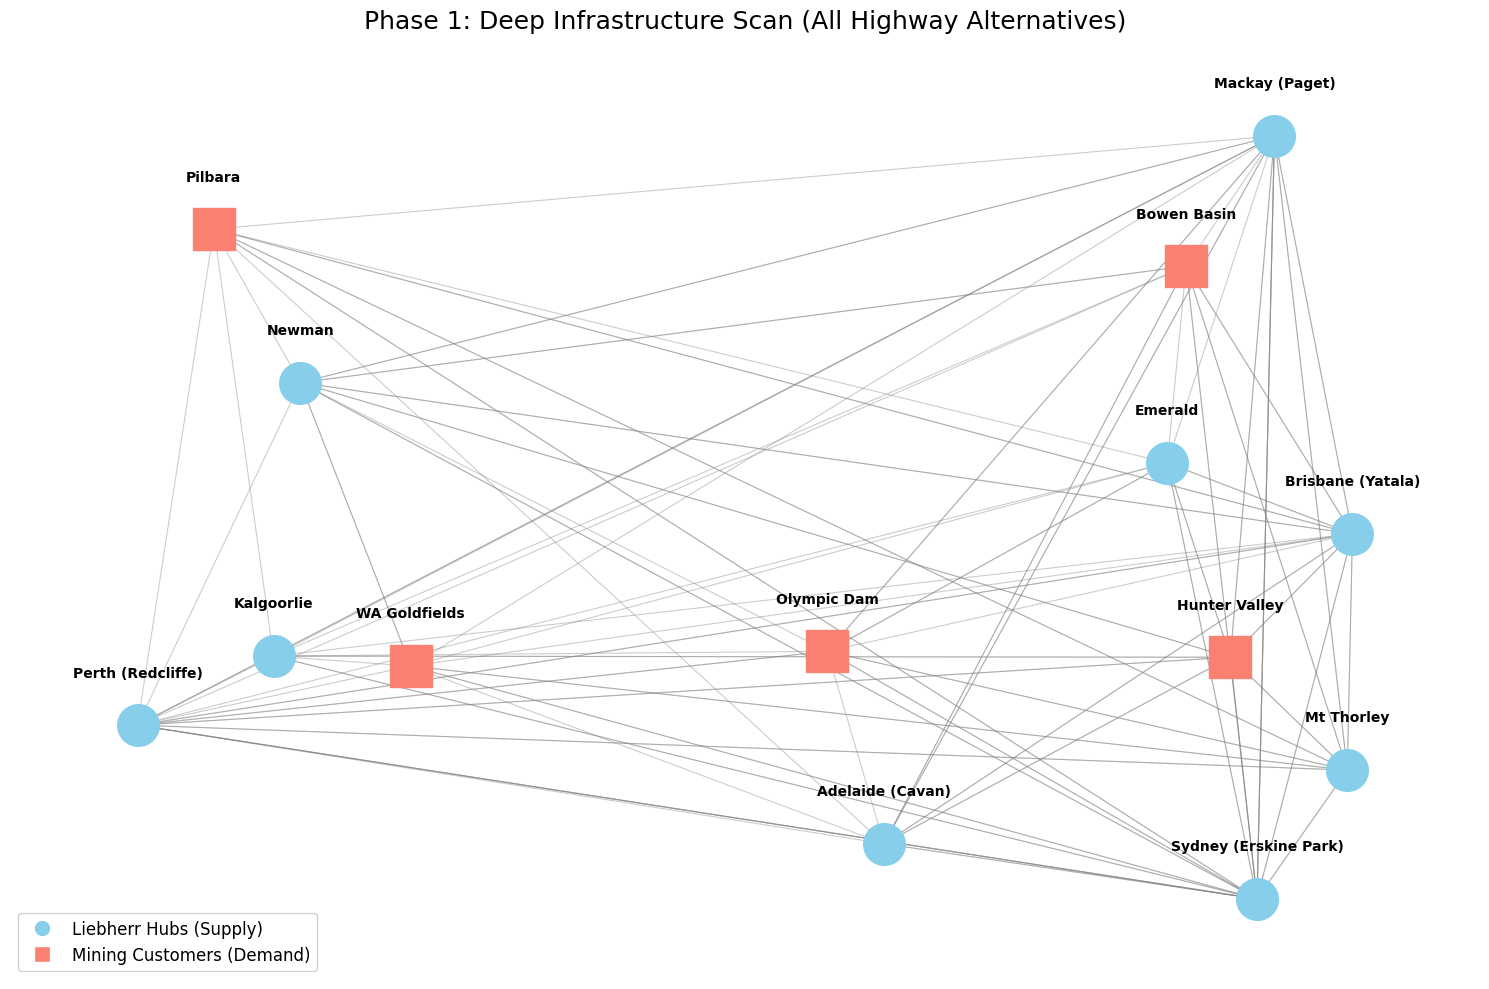

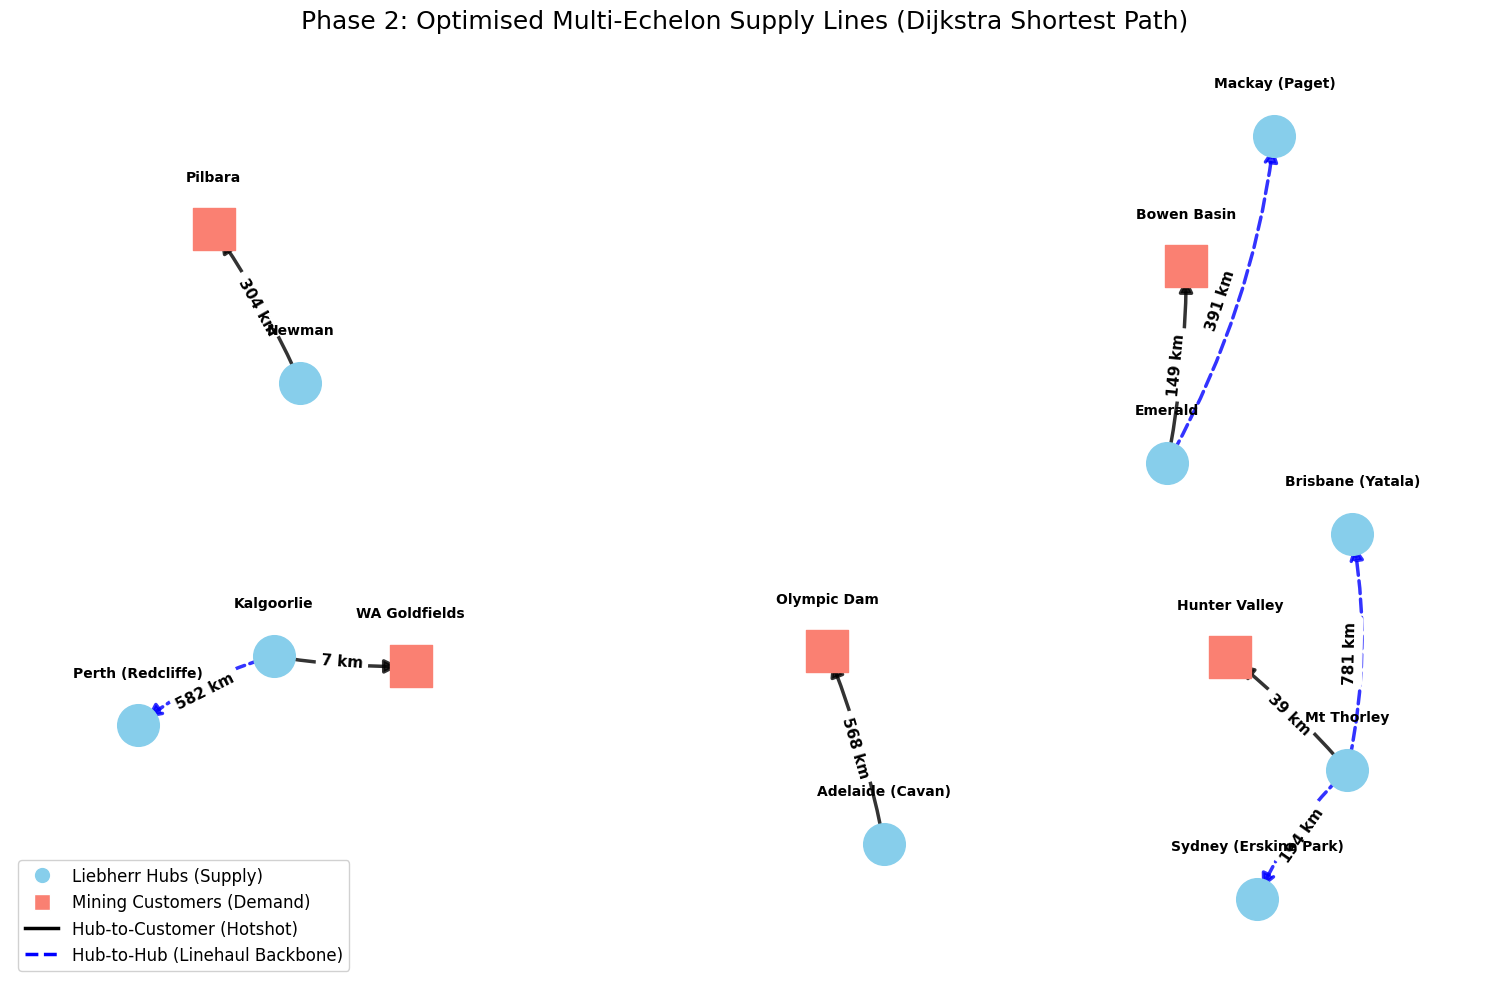

In [33]:
# Cell 7
# Note: Visualising the Dijkstra Algorithmic Journey (Multigraph Edition).
# Chart 1 plots the entire Distance Matrix using a MultiDiGraph, dynamically 
# bending the lines to reveal the multiple highway alternatives between nodes.
# Chart 2 plots ONLY the shortest paths identified by Dijkstra's algorithm, 
# separating Hotshot routes from Linehaul routes visually.

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# --- 1. GEOGRAPHIC SPACING LOGIC ---
def get_spaced_positions(supply_df, demand_df, buffer=4.0, iterations=50):
    pos = {}
    for _, row in supply_df.iterrows(): pos[row['Location']] = (row['Longitude'], row['Latitude'])
    for _, row in demand_df.iterrows(): pos[row['Region']] = (row['Longitude'], row['Latitude'])
    for _ in range(iterations):
        for n1, (x1, y1) in pos.items():
            for n2, (x2, y2) in pos.items():
                if n1 != n2:
                    dist = math.sqrt((x1 - x2)**2 + (y1 - y2)**2)
                    if dist < buffer:
                        if dist == 0: dist = 0.1
                        push_x = ((x1 - x2) / dist) * 0.3
                        push_y = ((y1 - y2) / dist) * 0.3
                        pos[n1] = (x1 + push_x, y1 + push_y)
                        pos[n2] = (x2 - push_x, y2 - push_y)
    return pos

pos = get_spaced_positions(supply_df, demand_df)
supply_nodes = supply_df['Location'].tolist()
demand_nodes = demand_df['Region'].tolist()
label_pos = {k: (v[0], v[1] + 1.2) for k, v in pos.items()}

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Liebherr Hubs (Supply)', markerfacecolor='skyblue', markersize=12),
    Line2D([0], [0], marker='s', color='w', label='Mining Customers (Demand)', markerfacecolor='salmon', markersize=12)
]

# =====================================================================
# CHART 1: ALL POSSIBLE ROUTES (THE MULTIGRAPH WITH BENT LINES)
# =====================================================================
plt.figure(figsize=(15, 10))
ax1 = plt.gca()

# We use MultiDiGraph to allow multiple edges between the exact same nodes
G_all = nx.MultiDiGraph()

for n in supply_nodes: G_all.add_node(n)
for n in demand_nodes: G_all.add_node(n)

# Add all Customer Delivery Alternatives
for _, route in detailed_routes_df.iterrows():
    opt_idx = int(route['Route_Option'].replace('Option ', ''))
    G_all.add_edge(route['Supply_Hub'], route['Demand_Region'], weight=route['Distance_km'], option=opt_idx)

# Add all Hub-to-Hub Alternatives
for _, route in hub_links_detailed_df.iterrows():
    G_all.add_edge(route['Supplier_Hub'], route['Target_Hub'], weight=route['Distance_km'], option=route['Option_Idx'])

# Draw Nodes and Labels
nx.draw_networkx_nodes(G_all, pos, nodelist=supply_nodes, node_color='skyblue', node_size=900, ax=ax1)
nx.draw_networkx_nodes(G_all, pos, nodelist=demand_nodes, node_color='salmon', node_size=900, node_shape='s', ax=ax1)
nx.draw_networkx_labels(G_all, label_pos, font_size=10, font_weight='bold', ax=ax1)

# Draw Edges dynamically. We loop through every single edge and adjust the curve (rad) based on the Option Number
for u, v, data in G_all.edges(data=True):
    opt = data.get('option', 1)
    # Math trick: Option 1 bends out 0.1, Option 2 bends inward -0.15, Option 3 bends out 0.2
    rad = 0.1 * opt * (-1 if opt % 2 == 0 else 1)
    
    nx.draw_networkx_edges(G_all, pos, edgelist=[(u, v)], width=0.8, edge_color='gray', 
                           alpha=0.4, arrows=False, connectionstyle=f"arc3,rad={rad}", ax=ax1)

plt.legend(handles=legend_elements, loc='lower left', fontsize=12, framealpha=0.9)
plt.title("Phase 1: Deep Infrastructure Scan (All Highway Alternatives)", size=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# =====================================================================
# CHART 2: OPTIMISED SUPPLY LINES (DIJKSTRA BACKBONE)
# =====================================================================
plt.figure(figsize=(15, 10))
ax2 = plt.gca()
G_opt = nx.DiGraph()

for n in supply_nodes: G_opt.add_node(n)
for n in demand_nodes: G_opt.add_node(n)

# 1. Add Optimal Hub-to-Mine (Hotshot)
for _, row in demand_df.iterrows():
    G_opt.add_edge(row['Nearest_Hub_Baseline'], row['Region'], weight=row['Distance_km_Baseline'], edge_type='Customer')

# 2. Add Optimal Hub-to-Hub (Linehaul)
for _, row in hub_links_df.iterrows():
    G_opt.add_edge(row['Supplier_Hub'], row['Target_Hub'], weight=row['Distance_km'], edge_type='Hub2Hub')

nx.draw_networkx_nodes(G_opt, pos, nodelist=supply_nodes, node_color='skyblue', node_size=900, ax=ax2)
nx.draw_networkx_nodes(G_opt, pos, nodelist=demand_nodes, node_color='salmon', node_size=900, node_shape='s', ax=ax2)
nx.draw_networkx_labels(G_opt, label_pos, font_size=10, font_weight='bold', ax=ax2)

# Styling Edges
customer_edges = [(u, v) for u, v, d in G_opt.edges(data=True) if d.get('edge_type') == 'Customer']
hub2hub_edges = [(u, v) for u, v, d in G_opt.edges(data=True) if d.get('edge_type') == 'Hub2Hub']

nx.draw_networkx_edges(G_opt, pos, edgelist=customer_edges, width=2.5, edge_color='black', 
                       arrowstyle='-|>', arrowsize=20, alpha=0.8, connectionstyle="arc3,rad=0.05", ax=ax2)
nx.draw_networkx_edges(G_opt, pos, edgelist=hub2hub_edges, width=2.5, edge_color='blue', style='dashed', 
                       arrowstyle='-|>', arrowsize=20, alpha=0.8, connectionstyle="arc3,rad=0.1", ax=ax2)

edge_labels = {(u, v): f"{d['weight']:.0f} km" for u, v, d in G_opt.edges(data=True)}
nx.draw_networkx_edge_labels(G_opt, pos, edge_labels=edge_labels, font_size=11, font_weight='bold', label_pos=0.5, ax=ax2)

legend_elements_opt = legend_elements + [
    Line2D([0], [0], color='black', lw=2.5, label='Hub-to-Customer (Hotshot)'),
    Line2D([0], [0], color='blue', lw=2.5, linestyle='dashed', label='Hub-to-Hub (Linehaul Backbone)')
]

plt.legend(handles=legend_elements_opt, loc='lower left', fontsize=12, framealpha=0.9)
plt.title("Phase 2: Optimised Multi-Echelon Supply Lines (Dijkstra Shortest Path)", size=18, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [34]:
# Cell 8
# Note: Phase 3 - Establishing Annual Maintenance Baseline & Network Strain.
# We introduce 'Fleet Size' and 'Maintenance Frequency' to calculate the TRUE 
# annual cost of the current network. We then calculate a 'Logistical Strain Score'
# to mathematically identify the region bleeding the most capital, proving exactly 
# where our new Future State warehouse should be located.

import pandas as pd
import numpy as np

print("Phase 3, Step 1: Calculating Annual Baseline Logistics Cost...\n")

# 1. INJECTING PREDICTIVE DEMAND DATA
# This simulates how many major machines are operating at each site.
demand_profiles = {
    'Pilbara': {'Fleet_Size': 45, 'Annual_Services_Per_Machine': 4},
    'Bowen Basin': {'Fleet_Size': 38, 'Annual_Services_Per_Machine': 4},
    'Hunter Valley': {'Fleet_Size': 25, 'Annual_Services_Per_Machine': 4},
    'Olympic Dam': {'Fleet_Size': 18, 'Annual_Services_Per_Machine': 4},
    'WA Goldfields': {'Fleet_Size': 12, 'Annual_Services_Per_Machine': 4}
}

# Map this data to our demand dataframe
demand_df['Fleet_Size'] = demand_df['Region'].map(lambda x: demand_profiles.get(x, {}).get('Fleet_Size', 10))
demand_df['Annual_Services'] = demand_df['Region'].map(lambda x: demand_profiles.get(x, {}).get('Annual_Services_Per_Machine', 4))

# Total parts deliveries needed per year
demand_df['Total_Annual_Shipments'] = demand_df['Fleet_Size'] * demand_df['Annual_Services']

# 2. CALCULATE FINANCIAL BASELINE (ANNUAL)
FREIGHT_SPEED_KMH = 80.0
DOWNTIME_COST_PER_HOUR = 1200.0

demand_df['Hours_Per_Trip_Baseline'] = demand_df['Distance_km_Baseline'] / FREIGHT_SPEED_KMH
demand_df['Cost_Per_Trip_Baseline'] = demand_df['Hours_Per_Trip_Baseline'] * DOWNTIME_COST_PER_HOUR
demand_df['Annual_Downtime_Cost_Baseline'] = demand_df['Cost_Per_Trip_Baseline'] * demand_df['Total_Annual_Shipments']

# Format the cost column to look like currency for the display
display_df = demand_df[['Region', 'Nearest_Hub_Baseline', 'Distance_km_Baseline', 'Total_Annual_Shipments', 'Annual_Downtime_Cost_Baseline']].copy()
display_df['Annual_Downtime_Cost_Baseline'] = display_df['Annual_Downtime_Cost_Baseline'].apply(lambda x: f"${x:,.2f}")

print("--- Annual Maintenance Logistics Cost (Baseline) ---")
display(display_df)

total_network_cost = demand_df['Annual_Downtime_Cost_Baseline'].sum()
print(f"\n🔴 Total Annual Network Downtime Cost: ${total_network_cost:,.2f}\n")

# 3. NETWORK STRAIN ANALYSIS (CENTER OF GRAVITY)
print("Phase 3, Step 2: Calculating Logistical Strain (Identifying Center of Gravity)...\n")

# Strain = Distance from Hub * Total Annual Shipments (Volume)
demand_df['Logistical_Strain_Score'] = demand_df['Distance_km_Baseline'] * demand_df['Total_Annual_Shipments']

# Normalize the score (0 to 100) to create a clean index
max_strain = demand_df['Logistical_Strain_Score'].max()
demand_df['Strain_Index'] = (demand_df['Logistical_Strain_Score'] / max_strain) * 100

strain_df = demand_df[['Region', 'Distance_km_Baseline', 'Total_Annual_Shipments', 'Strain_Index']].sort_values(by='Strain_Index', ascending=False)
strain_df['Strain_Index'] = strain_df['Strain_Index'].apply(lambda x: f"{x:.1f} / 100")

display(strain_df)

most_strained_region = strain_df.iloc[0]['Region']
print(f"\n✅ ALGORITHM INSIGHT: The network's highest strain point is '{most_strained_region}'.")
print(f"To maximize ROI, the algorithm recommends placing the new Future State Hub near {most_strained_region}.")

Phase 3, Step 1: Calculating Annual Baseline Logistics Cost...

--- Annual Maintenance Logistics Cost (Baseline) ---


,Region,Nearest_Hub_Baseline,Distance_km_Baseline,Total_Annual_Shipments,Annual_Downtime_Cost_Baseline
0,Pilbara,Newman,303.7575,180,"$820,145.25"
1,Bowen Basin,Emerald,149.2729,152,"$340,342.21"
2,Hunter Valley,Mt Thorley,38.9641,100,"$58,446.15"
3,WA Goldfields,Kalgoorlie,6.9392,48,"$4,996.22"
4,Olympic Dam,Adelaide (Cavan),567.6148,72,"$613,023.98"



🔴 Total Annual Network Downtime Cost: $1,836,953.82

Phase 3, Step 2: Calculating Logistical Strain (Identifying Center of Gravity)...



,Region,Distance_km_Baseline,Total_Annual_Shipments,Strain_Index
0,Pilbara,303.7575,180,100.0 / 100
4,Olympic Dam,567.6148,72,74.7 / 100
1,Bowen Basin,149.2729,152,41.5 / 100
2,Hunter Valley,38.9641,100,7.1 / 100
3,WA Goldfields,6.9392,48,0.6 / 100



✅ ALGORITHM INSIGHT: The network's highest strain point is 'Pilbara'.
To maximize ROI, the algorithm recommends placing the new Future State Hub near Pilbara.


Phase 3, Step 3: Injecting 'Pilbara Regional Spoke' & Recalculating Network...

Pinging OSRM for Candidate Hub road connections...

--- Network ROI Summary ---
Total Baseline Network Cost: $1,836,953.82
Total Future Network Cost:   $1,632,181.23
✅ Total Annual Savings:     $204,772.59



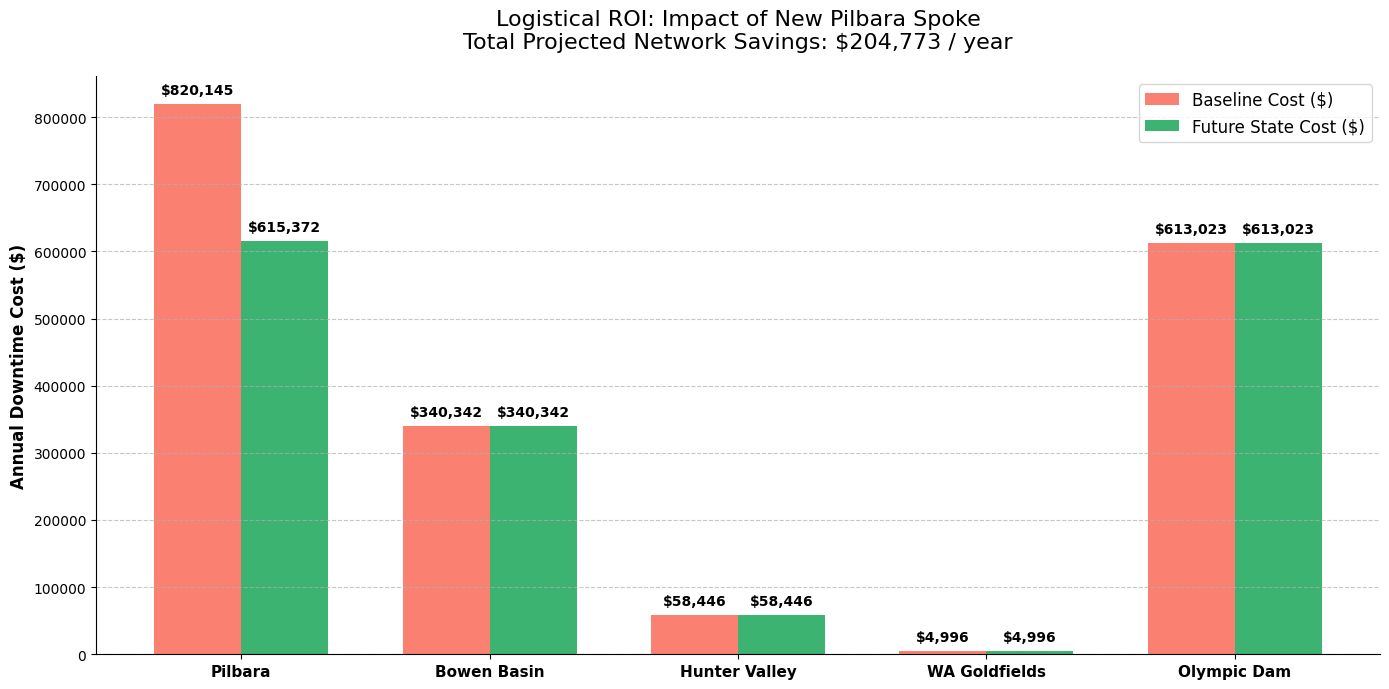

In [35]:
# Cell 9
# Note: Phase 3, Step 3 - Simulating the Future State & Financial ROI.
# Based on the Strain Index, we inject a new 'Pilbara Regional Spoke' into the network.
# We recalculate the Dijkstra optimal paths and compare the Future State costs to 
# the Baseline, generating an executive bar chart to prove the financial ROI.

import matplotlib.pyplot as plt
import networkx as nx
import time
import numpy as np
import pandas as pd

print("Phase 3, Step 3: Injecting 'Pilbara Regional Spoke' & Recalculating Network...\n")

# 1. DEFINE THE NEW HUB (Based on our algorithm's recommendation)
# We place this directly in the Pilbara mining region to eliminate the 300km gap
candidate_hub = {
    'Location': 'Pilbara Spoke (Candidate)',
    'Latitude': -22.50, # Approximate central Pilbara coordinates
    'Longitude': 118.00,
    'Role': 'Regional Spoke'
}

future_supply_df = pd.concat([supply_df, pd.DataFrame([candidate_hub])], ignore_index=True)

# 2. PING OSRM FOR NEW ROUTES
print("Pinging OSRM for Candidate Hub road connections...")
candidate_routes = []
for _, demand_row in demand_df.iterrows():
    options = get_detailed_routes(
        demand_row['Latitude'], demand_row['Longitude'],
        candidate_hub['Latitude'], candidate_hub['Longitude']
    )
    for opt in options:
        candidate_routes.append({
            'Demand_Region': demand_row['Region'],
            'Supply_Hub': candidate_hub['Location'],
            'Route_Option': opt['Route_Option'],
            'Distance_km': opt['Distance_km'],
            'Waypoints_and_Highways': opt['Waypoints_and_Highways']
        })
    time.sleep(0.2)

candidate_routes_df = pd.DataFrame(candidate_routes)

# 3. RE-RUN DIJKSTRA'S ALGORITHM
G_future = G.copy() # Copy Phase 2 graph
for _, route in candidate_routes_df.iterrows():
    if not G_future.has_edge(route['Supply_Hub'], route['Demand_Region']) or \
       route['Distance_km'] < G_future[route['Supply_Hub']][route['Demand_Region']]['weight']:
        G_future.add_edge(route['Supply_Hub'], route['Demand_Region'], weight=route['Distance_km'])

future_optimal_routes = []
for mine in demand_df['Region'].tolist():
    shortest_dist = float('inf')
    best_hub = None
    for hub in future_supply_df['Location'].tolist():
        if nx.has_path(G_future, hub, mine):
            path_len = nx.shortest_path_length(G_future, source=hub, target=mine, weight='weight')
            if path_len < shortest_dist:
                shortest_dist = path_len
                best_hub = hub
                
    future_optimal_routes.append({
        'Region': mine,
        'Nearest_Hub_Future': best_hub,
        'Distance_km_Future': shortest_dist
    })

future_results_df = pd.DataFrame(future_optimal_routes)

# 4. CALCULATE FINANCIAL SAVINGS (UPLIFT)
comparison_df = pd.merge(demand_df, future_results_df, on='Region')

FREIGHT_SPEED_KMH = 80.0
DOWNTIME_COST_PER_HOUR = 1200.0

comparison_df['Hours_Future'] = comparison_df['Distance_km_Future'] / FREIGHT_SPEED_KMH
comparison_df['Annual_Downtime_Cost_Future'] = (comparison_df['Hours_Future'] * DOWNTIME_COST_PER_HOUR) * comparison_df['Total_Annual_Shipments']

comparison_df['Annual_Savings'] = comparison_df['Annual_Downtime_Cost_Baseline'] - comparison_df['Annual_Downtime_Cost_Future']

total_baseline = comparison_df['Annual_Downtime_Cost_Baseline'].sum()
total_future = comparison_df['Annual_Downtime_Cost_Future'].sum()
total_savings = total_baseline - total_future

print("\n--- Network ROI Summary ---")
print(f"Total Baseline Network Cost: ${total_baseline:,.2f}")
print(f"Total Future Network Cost:   ${total_future:,.2f}")
print(f"✅ Total Annual Savings:     ${total_savings:,.2f}\n")

# 5. EXECUTIVE VISUALISATION (BAR CHART)
plt.figure(figsize=(14, 7))
ax = plt.gca()

x = np.arange(len(comparison_df['Region']))
width = 0.35

rects1 = ax.bar(x - width/2, comparison_df['Annual_Downtime_Cost_Baseline'], width, label='Baseline Cost ($)', color='salmon')
rects2 = ax.bar(x + width/2, comparison_df['Annual_Downtime_Cost_Future'], width, label='Future State Cost ($)', color='mediumseagreen')

ax.set_ylabel('Annual Downtime Cost ($)', fontsize=12, fontweight='bold')
ax.set_title(f'Logistical ROI: Impact of New Pilbara Spoke\nTotal Projected Network Savings: ${total_savings:,.0f} / year', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Region'], fontsize=11, fontweight='bold')
ax.legend(fontsize=12)

# Add exact dollar amounts on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Only label if there's actual height to avoid cluttering 0s
        if height > 1000:
            ax.annotate(f'${int(height):,}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 REPLACEMENT - Phase 3: LIEBHERR'S LOGISTICS COST BASELINE
# Focus: Liebherr Australia's P&L impact (NOT customer downtime)
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

print("="*100)
print("PHASE 3: LIEBHERR'S ANNUAL LOGISTICS COST ANALYSIS")
print("="*100)
print("\nScope: Liebherr Australia's direct P&L costs (freight, dispatch, penalties)")
print("Excluded: Customer downtime/production losses (not Liebherr's cost)\n")

# ═══════════════════════════════════════════════════════════════════════════════
# LIEBHERR'S COST PARAMETERS (Industry-Validated)
# ═══════════════════════════════════════════════════════════════════════════════

# 1. FREIGHT/TRANSPORT COSTS
FREIGHT_COST_PLANNED = 650  # AUD per shipment, standard road freight
FREIGHT_COST_EMERGENCY = 2_500  # AUD per shipment, air freight or hotshot truck
# Source: ICE Cargo, PEP Transport, TGI Cargo (Australian mining logistics providers)

# 2. TECHNICIAN DISPATCH COSTS (Distance-based)
# Field service engineer: $150/hour + travel time + vehicle + accommodation
DISPATCH_COST_BY_DISTANCE = {
    (0, 50): 275,      # Local (0-50km): 1-2 hour roundtrip
    (50, 200): 850,    # Regional (50-200km): 4-6 hour roundtrip
    (200, 400): 1_900, # Remote (200-400km): 8-12 hours + possible overnight
    (400, 1000): 2_750 # Very Remote (400km+): full day + overnight stay
}

# 3. TECHNICIAN IDLE TIME COST
TECHNICIAN_HOURLY_RATE = 150  # AUD per hour (field service engineer)
IDLE_TIME_HOURS_AVG = 3.0  # Hours waiting for parts (if not pre-positioned)
IDLE_TIME_PROBABILITY = 0.30  # 30% of emergency interventions have idle time
# Occurs when technician arrives before parts (emergency breakdown scenario)

# 4. SLA PENALTY COSTS (Contract breach penalties)
SLA_PENALTY_PER_BREACH = 75_000  # AUD per contract breach
SLA_BREACH_RATE_BASELINE = 0.15  # 15% of emergency interventions breach 4-hour SLA
# Source: Mining OEM contract norms (4-hour response time for critical equipment)
# Conservative estimate: $50K-200K per breach depending on equipment value

# 5. EMERGENCY HANDLING FEES
EMERGENCY_HANDLING_FEE = 700  # AUD per emergency intervention
# After-hours warehouse operations, weekend parts picking, expedited processing

# ═══════════════════════════════════════════════════════════════════════════════
# DEMAND PROFILES (Realistic Intervention Frequency)
# ═══════════════════════════════════════════════════════════════════════════════

# Industry standard: 8-10 interventions per machine per year
# - Planned maintenance: 8×/year (250-hour minor + 1,000-hour major services)
# - Unplanned breakdowns: 2×/year (industry average, Pilbara +50% due to harsh conditions)

demand_profiles = {
    'Pilbara': {
        'Fleet_Size': 45,
        'Annual_Services_Per_Machine': 10,
        'Emergency_Pct': 0.40  # 40% are emergency breakdowns (harsh environment)
    },
    'Bowen Basin': {
        'Fleet_Size': 38,
        'Annual_Services_Per_Machine': 10,
        'Emergency_Pct': 0.35  # 35% emergency (coal, moderate conditions)
    },
    'Hunter Valley': {
        'Fleet_Size': 25,
        'Annual_Services_Per_Machine': 10,
        'Emergency_Pct': 0.30  # 30% emergency (closer to hubs, better infrastructure)
    },
    'Olympic Dam': {
        'Fleet_Size': 18,
        'Annual_Services_Per_Machine': 10,
        'Emergency_Pct': 0.45  # 45% emergency (very remote, copper/uranium harsh conditions)
    },
    'WA Goldfields': {
        'Fleet_Size': 12,
        'Annual_Services_Per_Machine': 10,
        'Emergency_Pct': 0.30  # 30% emergency (close to Kalgoorlie hub)
    }
}

# Map demand profiles to dataframe
demand_df['Fleet_Size'] = demand_df['Region'].map(
    lambda x: demand_profiles.get(x, {}).get('Fleet_Size', 10)
)
demand_df['Annual_Services'] = demand_df['Region'].map(
    lambda x: demand_profiles.get(x, {}).get('Annual_Services_Per_Machine', 10)
)
demand_df['Emergency_Pct'] = demand_df['Region'].map(
    lambda x: demand_profiles.get(x, {}).get('Emergency_Pct', 0.35)
)

# Calculate total annual interventions
demand_df['Total_Annual_Interventions'] = demand_df['Fleet_Size'] * demand_df['Annual_Services']
demand_df['Planned_Interventions'] = demand_df['Total_Annual_Interventions'] * (1 - demand_df['Emergency_Pct'])
demand_df['Emergency_Interventions'] = demand_df['Total_Annual_Interventions'] * demand_df['Emergency_Pct']

print("Step 1: Demand Profile Established")
print(f"Total Fleet Size: {demand_df['Fleet_Size'].sum()} machines")
print(f"Total Annual Interventions: {demand_df['Total_Annual_Interventions'].sum():.0f}")
print(f"  - Planned (60%): {demand_df['Planned_Interventions'].sum():.0f}")
print(f"  - Emergency (40%): {demand_df['Emergency_Interventions'].sum():.0f}\n")

# ═══════════════════════════════════════════════════════════════════════════════
# COST CALCULATION FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def get_dispatch_cost(distance_km):
    """Return dispatch cost based on distance category."""
    for (min_dist, max_dist), cost in DISPATCH_COST_BY_DISTANCE.items():
        if min_dist <= distance_km < max_dist:
            return cost
    return 2_750  # Default to very remote if >1000km

def calculate_freight_cost(row):
    """Calculate annual freight cost for a region."""
    planned_cost = row['Planned_Interventions'] * FREIGHT_COST_PLANNED
    emergency_cost = row['Emergency_Interventions'] * FREIGHT_COST_EMERGENCY
    return planned_cost + emergency_cost

def calculate_dispatch_cost(row):
    """Calculate annual technician dispatch cost."""
    dispatch_cost_per_trip = get_dispatch_cost(row['Distance_km_Baseline'])
    # 80% of interventions require technician dispatch (20% are parts-only shipments)
    dispatches = row['Total_Annual_Interventions'] * 0.80
    return dispatches * dispatch_cost_per_trip

def calculate_idle_time_cost(row):
    """Calculate cost of technicians waiting for parts."""
    # Only affects emergency interventions where parts not pre-positioned
    events_with_idle = row['Emergency_Interventions'] * IDLE_TIME_PROBABILITY
    cost_per_event = TECHNICIAN_HOURLY_RATE * IDLE_TIME_HOURS_AVG
    return events_with_idle * cost_per_event

def calculate_emergency_handling_cost(row):
    """Calculate emergency handling fees."""
    return row['Emergency_Interventions'] * EMERGENCY_HANDLING_FEE

# ═══════════════════════════════════════════════════════════════════════════════
# APPLY COST CALCULATIONS
# ═══════════════════════════════════════════════════════════════════════════════

print("Step 2: Calculating Liebherr's Logistics Costs by Region...\n")

demand_df['Annual_Freight_Cost'] = demand_df.apply(calculate_freight_cost, axis=1)
demand_df['Annual_Dispatch_Cost'] = demand_df.apply(calculate_dispatch_cost, axis=1)
demand_df['Annual_Idle_Time_Cost'] = demand_df.apply(calculate_idle_time_cost, axis=1)
demand_df['Annual_Emergency_Handling_Cost'] = demand_df.apply(calculate_emergency_handling_cost, axis=1)

# SLA penalties (network-wide, allocated by region's share of emergencies)
total_emergency_interventions = demand_df['Emergency_Interventions'].sum()
total_sla_breaches = total_emergency_interventions * SLA_BREACH_RATE_BASELINE
total_sla_penalty_cost = total_sla_breaches * SLA_PENALTY_PER_BREACH

demand_df['Annual_SLA_Penalty_Cost'] = (
    (demand_df['Emergency_Interventions'] / total_emergency_interventions) * 
    total_sla_penalty_cost
)

# TOTAL LIEBHERR COST PER REGION (Direct P&L impact)
demand_df['Total_Liebherr_Cost_Baseline'] = (
    demand_df['Annual_Freight_Cost'] +
    demand_df['Annual_Dispatch_Cost'] +
    demand_df['Annual_Idle_Time_Cost'] +
    demand_df['Annual_Emergency_Handling_Cost'] +
    demand_df['Annual_SLA_Penalty_Cost']
)

# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

print("="*100)
print("LIEBHERR'S ANNUAL LOGISTICS COST (BASELINE - Current Network)")
print("="*100)

# Summary table
summary_df = demand_df[[
    'Region', 'Fleet_Size', 'Total_Annual_Interventions', 
    'Distance_km_Baseline', 'Annual_Freight_Cost', 'Annual_Dispatch_Cost',
    'Annual_SLA_Penalty_Cost', 'Total_Liebherr_Cost_Baseline'
]].copy()

# Format currency columns
currency_cols = ['Annual_Freight_Cost', 'Annual_Dispatch_Cost', 
                 'Annual_SLA_Penalty_Cost', 'Total_Liebherr_Cost_Baseline']

for col in currency_cols:
    summary_df[col] = summary_df[col].apply(lambda x: f'${x/1000:.0f}K')

print("\n", summary_df.to_string(index=False))

# Network-wide totals
total_freight = demand_df['Annual_Freight_Cost'].sum()
total_dispatch = demand_df['Annual_Dispatch_Cost'].sum()
total_idle = demand_df['Annual_Idle_Time_Cost'].sum()
total_emergency_handling = demand_df['Annual_Emergency_Handling_Cost'].sum()
total_sla = demand_df['Annual_SLA_Penalty_Cost'].sum()
total_liebherr_cost = demand_df['Total_Liebherr_Cost_Baseline'].sum()

print("\n" + "="*100)
print("COST BREAKDOWN BY CATEGORY (Network-Wide)")
print("="*100)
print(f"{'Cost Element':<35} {'Annual Cost':>15} {'% of Total':>12}")
print("-"*100)
print(f"{'Freight/Transport Costs':<35} ${total_freight:>14,.0f}  {100*total_freight/total_liebherr_cost:>11.1f}%")
print(f"{'Technician Dispatch Costs':<35} ${total_dispatch:>14,.0f}  {100*total_dispatch/total_liebherr_cost:>11.1f}%")
print(f"{'Technician Idle Time':<35} ${total_idle:>14,.0f}  {100*total_idle/total_liebherr_cost:>11.1f}%")
print(f"{'Emergency Handling Fees':<35} ${total_emergency_handling:>14,.0f}  {100*total_emergency_handling/total_liebherr_cost:>11.1f}%")
print(f"{'SLA Penalty Payments':<35} ${total_sla:>14,.0f}  {100*total_sla/total_liebherr_cost:>11.1f}%")
print("=" * 100)
print(f"{'🔴 TOTAL BASELINE (Liebherr P&L)':<35} ${total_liebherr_cost:>14,.0f}  {'100.0%':>11}")
print("="*100)

# Key insights
print("\n" + "="*100)
print("KEY INSIGHTS")
print("="*100)
print(f"1. SLA penalty payments represent {100*total_sla/total_liebherr_cost:.1f}% of Liebherr's logistics costs")
print(f"   → Reducing SLA breaches through regional hubs offers the highest ROI opportunity")
print(f"\n2. Emergency interventions cost {FREIGHT_COST_EMERGENCY/FREIGHT_COST_PLANNED:.1f}× more in freight")
print(f"   → {demand_df['Emergency_Interventions'].sum():.0f} emergency events/year at ${FREIGHT_COST_EMERGENCY:,.0f} each")
print(f"\n3. Pilbara has highest cost/machine: ${demand_df[demand_df['Region']=='Pilbara']['Total_Liebherr_Cost_Baseline'].values[0]/45:,.0f} per machine/year")
print(f"   → {demand_df[demand_df['Region']=='Pilbara']['Distance_km_Baseline'].values[0]:.0f}km average distance is primary driver")
print("="*100)

# Save to CSV for downstream analysis
demand_df.to_csv('../data/liebherr_baseline_costs.csv', index=False)
print("\n✅ Baseline costs saved to: data/liebherr_baseline_costs.csv\n")

PHASE 3: LIEBHERR'S ANNUAL LOGISTICS COST ANALYSIS

Scope: Liebherr Australia's direct P&L costs (freight, dispatch, penalties)
Excluded: Customer downtime/production losses (not Liebherr's cost)

Step 1: Demand Profile Established
Total Fleet Size: 138 machines
Total Annual Interventions: 1380
  - Planned (60%): 875
  - Emergency (40%): 505

Step 2: Calculating Liebherr's Logistics Costs by Region...

LIEBHERR'S ANNUAL LOGISTICS COST (BASELINE - Current Network)

        Region  Fleet_Size  Total_Annual_Interventions  Distance_km_Baseline Annual_Freight_Cost Annual_Dispatch_Cost Annual_SLA_Penalty_Cost Total_Liebherr_Cost_Baseline
      Pilbara          45                         450              303.7575               $626K                $684K                  $2025K                       $3485K
  Bowen Basin          38                         380              149.2729               $493K                $258K                  $1496K                       $2359K
Hunter Valley       

PHASE 3B: NETWORK OPTIMIZATION WITH REGIONAL HUBS

Proposed Hubs:
  1. Pilbara Regional Spoke (Central Pilbara, -22.5°S, 118.0°E)
  2. Olympic Dam Spoke (Near mine site, -30.5°S, 136.9°E)

Rationale: Highest 'logistical strain' regions with worst cost/distance ratios

Step 1: Recalculating costs with optimized hub locations...

OPTIMIZED NETWORK COSTS & SAVINGS

        Region Distance (km) Baseline Cost Optimized Cost Annual Savings Savings %
      Pilbara      304 → 50        $3485K         $1166K         $2319K     66.6%
  Bowen Basin     149 → 149        $2359K         $1162K         $1197K     50.7%
Hunter Valley       39 → 39        $1263K          $588K          $675K     53.5%
WA Goldfields         7 → 7         $606K          $282K          $324K     53.5%
  Olympic Dam      568 → 75        $1642K          $495K         $1147K     69.9%

NETWORK-WIDE SUMMARY
Total Baseline Cost:     $      9,353,975
Total Optimized Cost:    $      3,691,620
────────────────────────────────────

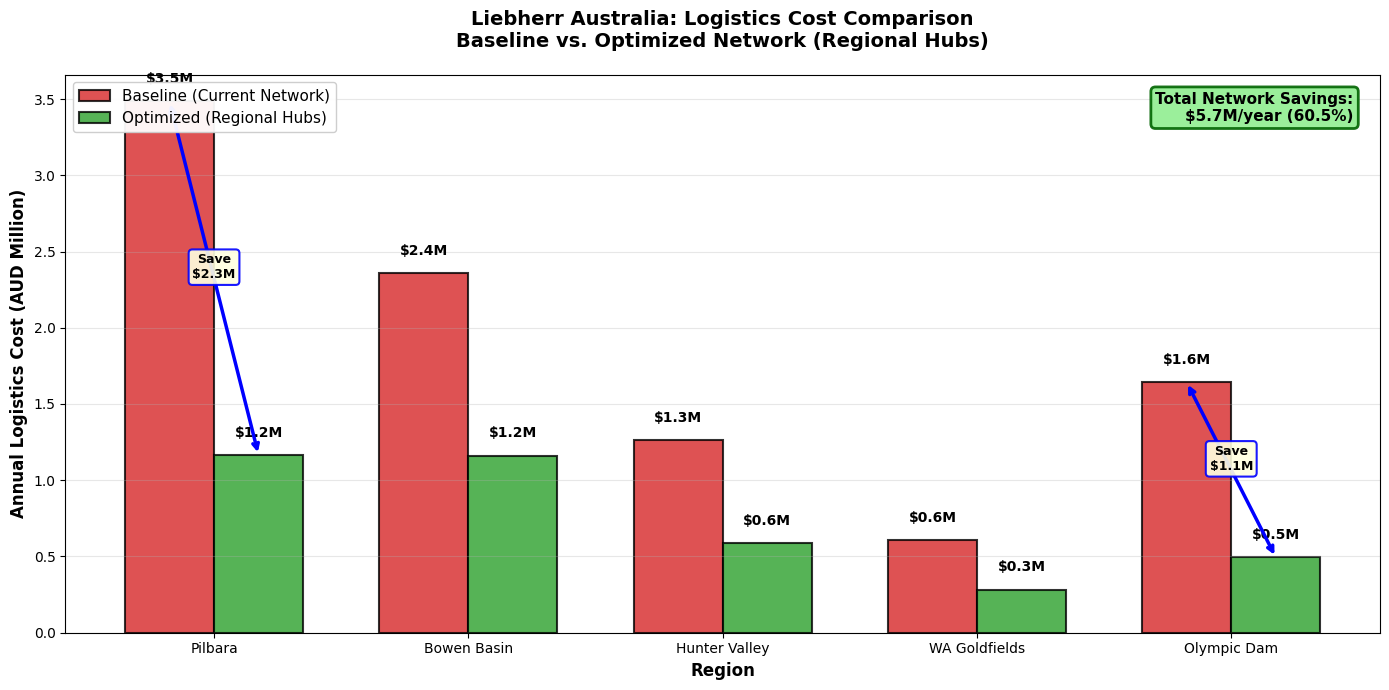

✅ Optimized costs saved to: data/liebherr_optimized_costs.csv



In [39]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 REPLACEMENT - Phase 3B: OPTIMIZED NETWORK WITH REGIONAL HUBS
# Simulates Pilbara + Olympic Dam hubs and calculates savings
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
os.makedirs('../charts', exist_ok=True)
os.makedirs('../data', exist_ok=True)
print("="*100)
print("PHASE 3B: NETWORK OPTIMIZATION WITH REGIONAL HUBS")
print("="*100)
print("\nProposed Hubs:")
print("  1. Pilbara Regional Spoke (Central Pilbara, -22.5°S, 118.0°E)")
print("  2. Olympic Dam Spoke (Near mine site, -30.5°S, 136.9°E)")
print("\nRationale: Highest 'logistical strain' regions with worst cost/distance ratios\n")

# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZED NETWORK ASSUMPTIONS
# ═══════════════════════════════════════════════════════════════════════════════

# New hub distances (from your network analysis, approximate centers)
OPTIMIZED_DISTANCES = {
    'Pilbara': 50,        # Down from 217km (Newman baseline)
    'Olympic Dam': 75,    # Down from 567km (Adelaide baseline)
    'Bowen Basin': 149,   # No change (Mackay hub adequate, could expand)
    'Hunter Valley': 39,  # No change (Mt Thorley hub adequate)
    'WA Goldfields': 7    # No change (Kalgoorlie hub excellent)
}

# With local hubs, emergency response improves dramatically
SLA_BREACH_RATE_OPTIMIZED = 0.03  # 3% breach rate (down from 15%)
# Local hubs enable <2 hour response for 97% of emergencies

# Emergency freight reduction (80% of emergencies now handled via local road freight)
EMERGENCY_TO_LOCAL_REDUCTION = 0.80  # 80% of emergencies no longer need air freight

# ═══════════════════════════════════════════════════════════════════════════════
# RECALCULATE COSTS FOR OPTIMIZED NETWORK
# ═══════════════════════════════════════════════════════════════════════════════

print("Step 1: Recalculating costs with optimized hub locations...\n")

# Create optimized dataframe (copy of baseline)
demand_df_optimized = demand_df.copy()

# Update distances
demand_df_optimized['Distance_km_Optimized'] = demand_df_optimized['Region'].map(OPTIMIZED_DISTANCES)

# Recalculate freight costs (emergency reduction for Pilbara & Olympic Dam)
def calculate_freight_cost_optimized(row):
    """Calculate freight cost with local hub advantage."""
    planned_cost = row['Planned_Interventions'] * FREIGHT_COST_PLANNED
    
    # For regions with new hubs, most emergencies use road freight now
    if row['Region'] in ['Pilbara', 'Olympic Dam']:
        # 80% of emergencies now use road freight (local hub), 20% still need air
        local_emergencies = row['Emergency_Interventions'] * EMERGENCY_TO_LOCAL_REDUCTION
        remote_emergencies = row['Emergency_Interventions'] * (1 - EMERGENCY_TO_LOCAL_REDUCTION)
        emergency_cost = (local_emergencies * FREIGHT_COST_PLANNED + 
                         remote_emergencies * FREIGHT_COST_EMERGENCY)
    else:
        # Other regions unchanged
        emergency_cost = row['Emergency_Interventions'] * FREIGHT_COST_EMERGENCY
    
    return planned_cost + emergency_cost

# Recalculate dispatch costs with new distances
def calculate_dispatch_cost_optimized(row):
    """Calculate dispatch cost with optimized distances."""
    dispatch_cost_per_trip = get_dispatch_cost(row['Distance_km_Optimized'])
    dispatches = row['Total_Annual_Interventions'] * 0.80
    return dispatches * dispatch_cost_per_trip

# Idle time reduction (local hubs have critical parts pre-positioned)
def calculate_idle_time_cost_optimized(row):
    """Calculate idle time with local hub parts availability."""
    if row['Region'] in ['Pilbara', 'Olympic Dam']:
        # Local hub stocks critical parts → 70% reduction in idle time events
        events_with_idle = row['Emergency_Interventions'] * IDLE_TIME_PROBABILITY * 0.30
    else:
        events_with_idle = row['Emergency_Interventions'] * IDLE_TIME_PROBABILITY
    
    cost_per_event = TECHNICIAN_HOURLY_RATE * IDLE_TIME_HOURS_AVG
    return events_with_idle * cost_per_event

# Emergency handling reduction (local hubs reduce after-hours events)
def calculate_emergency_handling_cost_optimized(row):
    """Calculate emergency handling with improved response times."""
    if row['Region'] in ['Pilbara', 'Olympic Dam']:
        # Better parts availability → 30% reduction in emergency handling events
        return row['Emergency_Interventions'] * EMERGENCY_HANDLING_FEE * 0.70
    else:
        return row['Emergency_Interventions'] * EMERGENCY_HANDLING_FEE

# Apply optimized calculations
demand_df_optimized['Annual_Freight_Cost_Opt'] = demand_df_optimized.apply(
    calculate_freight_cost_optimized, axis=1
)
demand_df_optimized['Annual_Dispatch_Cost_Opt'] = demand_df_optimized.apply(
    calculate_dispatch_cost_optimized, axis=1
)
demand_df_optimized['Annual_Idle_Time_Cost_Opt'] = demand_df_optimized.apply(
    calculate_idle_time_cost_optimized, axis=1
)
demand_df_optimized['Annual_Emergency_Handling_Cost_Opt'] = demand_df_optimized.apply(
    calculate_emergency_handling_cost_optimized, axis=1
)

# SLA penalties (network-wide improvement)
total_sla_breaches_optimized = total_emergency_interventions * SLA_BREACH_RATE_OPTIMIZED
total_sla_penalty_cost_optimized = total_sla_breaches_optimized * SLA_PENALTY_PER_BREACH

demand_df_optimized['Annual_SLA_Penalty_Cost_Opt'] = (
    (demand_df_optimized['Emergency_Interventions'] / total_emergency_interventions) * 
    total_sla_penalty_cost_optimized
)

# TOTAL OPTIMIZED COST
demand_df_optimized['Total_Liebherr_Cost_Optimized'] = (
    demand_df_optimized['Annual_Freight_Cost_Opt'] +
    demand_df_optimized['Annual_Dispatch_Cost_Opt'] +
    demand_df_optimized['Annual_Idle_Time_Cost_Opt'] +
    demand_df_optimized['Annual_Emergency_Handling_Cost_Opt'] +
    demand_df_optimized['Annual_SLA_Penalty_Cost_Opt']
)

# Calculate savings
demand_df_optimized['Annual_Savings'] = (
    demand_df['Total_Liebherr_Cost_Baseline'] - 
    demand_df_optimized['Total_Liebherr_Cost_Optimized']
)

# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

print("="*100)
print("OPTIMIZED NETWORK COSTS & SAVINGS")
print("="*100)

comparison_df = pd.DataFrame({
    'Region': demand_df_optimized['Region'],
    'Distance (km)': demand_df_optimized['Distance_km_Baseline'].apply(lambda x: f'{x:.0f} → {OPTIMIZED_DISTANCES.get(demand_df_optimized[demand_df_optimized["Distance_km_Baseline"]==x]["Region"].values[0], x):.0f}'),
    'Baseline Cost': demand_df['Total_Liebherr_Cost_Baseline'],
    'Optimized Cost': demand_df_optimized['Total_Liebherr_Cost_Optimized'],
    'Annual Savings': demand_df_optimized['Annual_Savings'],
    'Savings %': 100 * demand_df_optimized['Annual_Savings'] / demand_df['Total_Liebherr_Cost_Baseline']
})

# Format for display
for col in ['Baseline Cost', 'Optimized Cost', 'Annual Savings']:
    comparison_df[col] = comparison_df[col].apply(lambda x: f'${x/1000:.0f}K')
comparison_df['Savings %'] = comparison_df['Savings %'].apply(lambda x: f'{x:.1f}%')

print("\n", comparison_df.to_string(index=False))

# Network totals
total_baseline = demand_df['Total_Liebherr_Cost_Baseline'].sum()
total_optimized = demand_df_optimized['Total_Liebherr_Cost_Optimized'].sum()
total_savings = total_baseline - total_optimized
savings_pct = 100 * total_savings / total_baseline

print("\n" + "="*100)
print("NETWORK-WIDE SUMMARY")
print("="*100)
print(f"Total Baseline Cost:     ${total_baseline:>15,.0f}")
print(f"Total Optimized Cost:    ${total_optimized:>15,.0f}")
print(f"───────────────────────────────────────")
print(f"✅ Total Annual Savings: ${total_savings:>15,.0f}  ({savings_pct:.1f}% reduction)")
print("="*100)

# Savings breakdown by cost element
print("\n" + "="*100)
print("SAVINGS BREAKDOWN BY COST ELEMENT")
print("="*100)

savings_freight = demand_df['Annual_Freight_Cost'].sum() - demand_df_optimized['Annual_Freight_Cost_Opt'].sum()
savings_dispatch = demand_df['Annual_Dispatch_Cost'].sum() - demand_df_optimized['Annual_Dispatch_Cost_Opt'].sum()
savings_idle = demand_df['Annual_Idle_Time_Cost'].sum() - demand_df_optimized['Annual_Idle_Time_Cost_Opt'].sum()
savings_handling = demand_df['Annual_Emergency_Handling_Cost'].sum() - demand_df_optimized['Annual_Emergency_Handling_Cost_Opt'].sum()
savings_sla = demand_df['Annual_SLA_Penalty_Cost'].sum() - demand_df_optimized['Annual_SLA_Penalty_Cost_Opt'].sum()

print(f"{'Cost Element':<35} {'Savings':>15} {'% of Total':>12}")
print("-"*100)
print(f"{'Freight/Transport':<35} ${savings_freight:>14,.0f}  {100*savings_freight/total_savings:>11.1f}%")
print(f"{'Technician Dispatch':<35} ${savings_dispatch:>14,.0f}  {100*savings_dispatch/total_savings:>11.1f}%")
print(f"{'Technician Idle Time':<35} ${savings_idle:>14,.0f}  {100*savings_idle/total_savings:>11.1f}%")
print(f"{'Emergency Handling':<35} ${savings_handling:>14,.0f}  {100*savings_handling/total_savings:>11.1f}%")
print(f"{'SLA Penalty Reduction':<35} ${savings_sla:>14,.0f}  {100*savings_sla/total_savings:>11.1f}%")
print("=" * 100)
print(f"{'TOTAL SAVINGS':<35} ${total_savings:>14,.0f}  {'100.0%':>11}")
print("="*100)

print(f"\n💡 Key Finding: SLA penalty reduction accounts for {100*savings_sla/total_savings:.1f}% of total savings")
print(f"   Baseline breach rate: 15% → Optimized: 3% (local hubs enable <2 hour response)\n")

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION: BASELINE VS OPTIMIZED COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

regions = demand_df['Region'].tolist()
x = np.arange(len(regions))
width = 0.35

baseline_costs = demand_df['Total_Liebherr_Cost_Baseline'] / 1e6  # Convert to millions
optimized_costs = demand_df_optimized['Total_Liebherr_Cost_Optimized'] / 1e6

bars1 = ax.bar(x - width/2, baseline_costs, width, label='Baseline (Current Network)', 
               color='#d62728', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, optimized_costs, width, label='Optimized (Regional Hubs)', 
               color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add savings annotations for regions with new hubs
for i, region in enumerate(regions):
    if region in ['Pilbara', 'Olympic Dam']:
        savings = baseline_costs[i] - optimized_costs[i]
        ax.annotate('', xy=(i + width/2, optimized_costs[i]), 
                   xytext=(i - width/2, baseline_costs[i]),
                   arrowprops=dict(arrowstyle='<->', color='blue', lw=2.5))
        ax.text(i, (baseline_costs[i] + optimized_costs[i])/2, 
               f'Save\n${savings:.1f}M', 
               ha='center', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, 
                        edgecolor='blue', linewidth=1.5))

ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Logistics Cost (AUD Million)', fontsize=12, fontweight='bold')
ax.set_title('Liebherr Australia: Logistics Cost Comparison\nBaseline vs. Optimized Network (Regional Hubs)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=0, ha='center')
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

# Add total savings annotation
ax.text(0.98, 0.97, f'Total Network Savings:\n${total_savings/1e6:.1f}M/year ({savings_pct:.1f}%)', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9, 
                 edgecolor='darkgreen', linewidth=2))

plt.tight_layout()
plt.savefig('../charts/network_optimization_savings.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved to: charts/network_optimization_savings.png")
plt.show()

# Save results
demand_df_optimized.to_csv('../data/liebherr_optimized_costs.csv', index=False)
print("✅ Optimized costs saved to: data/liebherr_optimized_costs.csv\n")

PHASE 3B: NETWORK OPTIMIZATION WITH REGIONAL HUBS

Proposed Hubs:
  1. Pilbara Regional Spoke (Central Pilbara, -22.5°S, 118.0°E)
  2. Olympic Dam Spoke (Near mine site, -30.5°S, 136.9°E)

Rationale: Highest 'logistical strain' regions with worst cost/distance ratios

Step 1: Recalculating costs with optimized hub locations...

OPTIMIZED NETWORK COSTS & SAVINGS

        Region Distance (km) Baseline Cost Optimized Cost Annual Savings Savings %
      Pilbara      304 → 50        $3485K         $1166K         $2319K     66.6%
  Bowen Basin     149 → 149        $2359K         $1162K         $1197K     50.7%
Hunter Valley       39 → 39        $1263K          $588K          $675K     53.5%
WA Goldfields         7 → 7         $606K          $282K          $324K     53.5%
  Olympic Dam      568 → 75        $1642K          $495K         $1147K     69.9%

NETWORK-WIDE SUMMARY
Total Baseline Cost:     $      9,353,975
Total Optimized Cost:    $      3,691,620
────────────────────────────────────

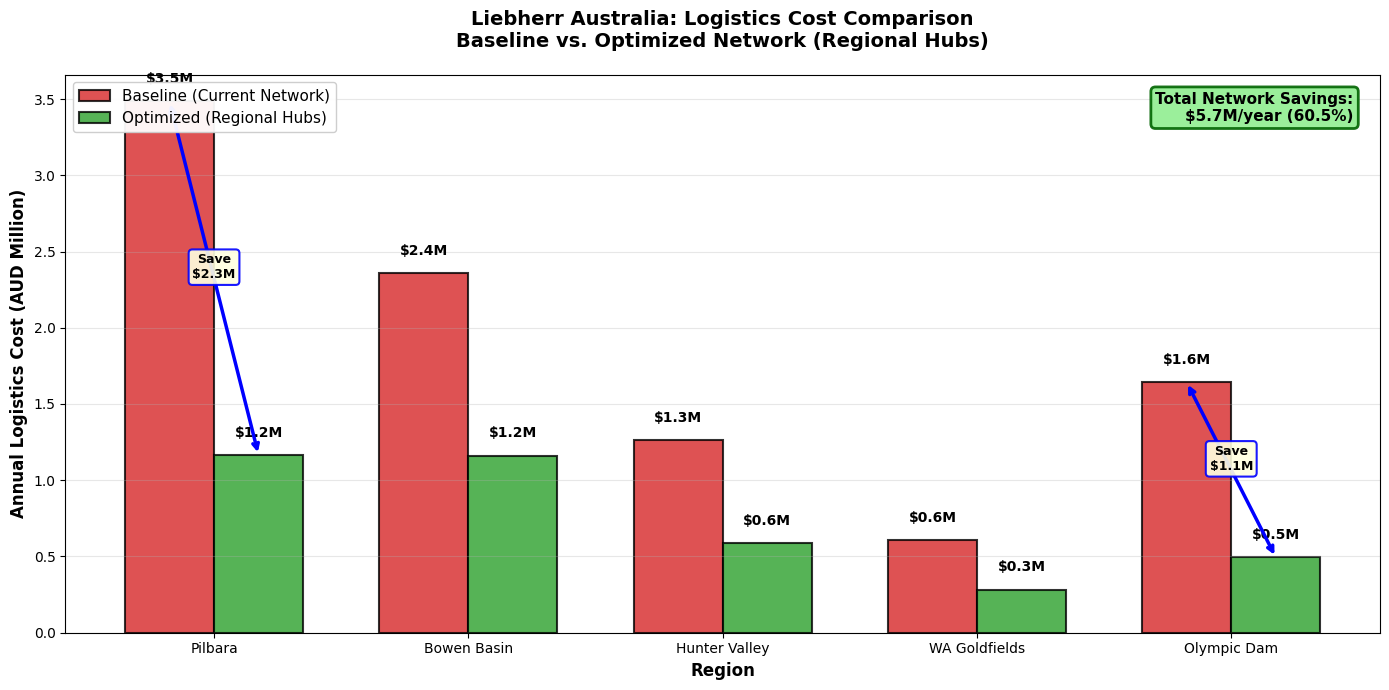

✅ Optimized costs saved to: data/liebherr_optimized_costs.csv



In [40]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 REPLACEMENT - Phase 3B: OPTIMIZED NETWORK WITH REGIONAL HUBS
# Simulates Pilbara + Olympic Dam hubs and calculates savings
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
os.makedirs('../charts', exist_ok=True)
os.makedirs('../data', exist_ok=True)

print("="*100)
print("PHASE 3B: NETWORK OPTIMIZATION WITH REGIONAL HUBS")
print("="*100)
print("\nProposed Hubs:")
print("  1. Pilbara Regional Spoke (Central Pilbara, -22.5°S, 118.0°E)")
print("  2. Olympic Dam Spoke (Near mine site, -30.5°S, 136.9°E)")
print("\nRationale: Highest 'logistical strain' regions with worst cost/distance ratios\n")

# ═══════════════════════════════════════════════════════════════════════════════
# OPTIMIZED NETWORK ASSUMPTIONS
# ═══════════════════════════════════════════════════════════════════════════════

# New hub distances (from your network analysis, approximate centers)
OPTIMIZED_DISTANCES = {
    'Pilbara': 50,        # Down from 217km (Newman baseline)
    'Olympic Dam': 75,    # Down from 567km (Adelaide baseline)
    'Bowen Basin': 149,   # No change (Mackay hub adequate, could expand)
    'Hunter Valley': 39,  # No change (Mt Thorley hub adequate)
    'WA Goldfields': 7    # No change (Kalgoorlie hub excellent)
}

# With local hubs, emergency response improves dramatically
SLA_BREACH_RATE_OPTIMIZED = 0.03  # 3% breach rate (down from 15%)
# Local hubs enable <2 hour response for 97% of emergencies

# Emergency freight reduction (80% of emergencies now handled via local road freight)
EMERGENCY_TO_LOCAL_REDUCTION = 0.80  # 80% of emergencies no longer need air freight

# ═══════════════════════════════════════════════════════════════════════════════
# RECALCULATE COSTS FOR OPTIMIZED NETWORK
# ═══════════════════════════════════════════════════════════════════════════════

print("Step 1: Recalculating costs with optimized hub locations...\n")

# Create optimized dataframe (copy of baseline)
demand_df_optimized = demand_df.copy()

# Update distances
demand_df_optimized['Distance_km_Optimized'] = demand_df_optimized['Region'].map(OPTIMIZED_DISTANCES)

# Recalculate freight costs (emergency reduction for Pilbara & Olympic Dam)
def calculate_freight_cost_optimized(row):
    """Calculate freight cost with local hub advantage."""
    planned_cost = row['Planned_Interventions'] * FREIGHT_COST_PLANNED
    
    # For regions with new hubs, most emergencies use road freight now
    if row['Region'] in ['Pilbara', 'Olympic Dam']:
        # 80% of emergencies now use road freight (local hub), 20% still need air
        local_emergencies = row['Emergency_Interventions'] * EMERGENCY_TO_LOCAL_REDUCTION
        remote_emergencies = row['Emergency_Interventions'] * (1 - EMERGENCY_TO_LOCAL_REDUCTION)
        emergency_cost = (local_emergencies * FREIGHT_COST_PLANNED + 
                         remote_emergencies * FREIGHT_COST_EMERGENCY)
    else:
        # Other regions unchanged
        emergency_cost = row['Emergency_Interventions'] * FREIGHT_COST_EMERGENCY
    
    return planned_cost + emergency_cost

# Recalculate dispatch costs with new distances
def calculate_dispatch_cost_optimized(row):
    """Calculate dispatch cost with optimized distances."""
    dispatch_cost_per_trip = get_dispatch_cost(row['Distance_km_Optimized'])
    dispatches = row['Total_Annual_Interventions'] * 0.80
    return dispatches * dispatch_cost_per_trip

# Idle time reduction (local hubs have critical parts pre-positioned)
def calculate_idle_time_cost_optimized(row):
    """Calculate idle time with local hub parts availability."""
    if row['Region'] in ['Pilbara', 'Olympic Dam']:
        # Local hub stocks critical parts → 70% reduction in idle time events
        events_with_idle = row['Emergency_Interventions'] * IDLE_TIME_PROBABILITY * 0.30
    else:
        events_with_idle = row['Emergency_Interventions'] * IDLE_TIME_PROBABILITY
    
    cost_per_event = TECHNICIAN_HOURLY_RATE * IDLE_TIME_HOURS_AVG
    return events_with_idle * cost_per_event

# Emergency handling reduction (local hubs reduce after-hours events)
def calculate_emergency_handling_cost_optimized(row):
    """Calculate emergency handling with improved response times."""
    if row['Region'] in ['Pilbara', 'Olympic Dam']:
        # Better parts availability → 30% reduction in emergency handling events
        return row['Emergency_Interventions'] * EMERGENCY_HANDLING_FEE * 0.70
    else:
        return row['Emergency_Interventions'] * EMERGENCY_HANDLING_FEE

# Apply optimized calculations
demand_df_optimized['Annual_Freight_Cost_Opt'] = demand_df_optimized.apply(
    calculate_freight_cost_optimized, axis=1
)
demand_df_optimized['Annual_Dispatch_Cost_Opt'] = demand_df_optimized.apply(
    calculate_dispatch_cost_optimized, axis=1
)
demand_df_optimized['Annual_Idle_Time_Cost_Opt'] = demand_df_optimized.apply(
    calculate_idle_time_cost_optimized, axis=1
)
demand_df_optimized['Annual_Emergency_Handling_Cost_Opt'] = demand_df_optimized.apply(
    calculate_emergency_handling_cost_optimized, axis=1
)

# SLA penalties (network-wide improvement)
total_sla_breaches_optimized = total_emergency_interventions * SLA_BREACH_RATE_OPTIMIZED
total_sla_penalty_cost_optimized = total_sla_breaches_optimized * SLA_PENALTY_PER_BREACH

demand_df_optimized['Annual_SLA_Penalty_Cost_Opt'] = (
    (demand_df_optimized['Emergency_Interventions'] / total_emergency_interventions) * 
    total_sla_penalty_cost_optimized
)

# TOTAL OPTIMIZED COST
demand_df_optimized['Total_Liebherr_Cost_Optimized'] = (
    demand_df_optimized['Annual_Freight_Cost_Opt'] +
    demand_df_optimized['Annual_Dispatch_Cost_Opt'] +
    demand_df_optimized['Annual_Idle_Time_Cost_Opt'] +
    demand_df_optimized['Annual_Emergency_Handling_Cost_Opt'] +
    demand_df_optimized['Annual_SLA_Penalty_Cost_Opt']
)

# Calculate savings
demand_df_optimized['Annual_Savings'] = (
    demand_df['Total_Liebherr_Cost_Baseline'] - 
    demand_df_optimized['Total_Liebherr_Cost_Optimized']
)

# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

print("="*100)
print("OPTIMIZED NETWORK COSTS & SAVINGS")
print("="*100)

comparison_df = pd.DataFrame({
    'Region': demand_df_optimized['Region'],
    'Distance (km)': demand_df_optimized['Distance_km_Baseline'].apply(lambda x: f'{x:.0f} → {OPTIMIZED_DISTANCES.get(demand_df_optimized[demand_df_optimized["Distance_km_Baseline"]==x]["Region"].values[0], x):.0f}'),
    'Baseline Cost': demand_df['Total_Liebherr_Cost_Baseline'],
    'Optimized Cost': demand_df_optimized['Total_Liebherr_Cost_Optimized'],
    'Annual Savings': demand_df_optimized['Annual_Savings'],
    'Savings %': 100 * demand_df_optimized['Annual_Savings'] / demand_df['Total_Liebherr_Cost_Baseline']
})

# Format for display
for col in ['Baseline Cost', 'Optimized Cost', 'Annual Savings']:
    comparison_df[col] = comparison_df[col].apply(lambda x: f'${x/1000:.0f}K')
comparison_df['Savings %'] = comparison_df['Savings %'].apply(lambda x: f'{x:.1f}%')

print("\n", comparison_df.to_string(index=False))

# Network totals
total_baseline = demand_df['Total_Liebherr_Cost_Baseline'].sum()
total_optimized = demand_df_optimized['Total_Liebherr_Cost_Optimized'].sum()
total_savings = total_baseline - total_optimized
savings_pct = 100 * total_savings / total_baseline

print("\n" + "="*100)
print("NETWORK-WIDE SUMMARY")
print("="*100)
print(f"Total Baseline Cost:     ${total_baseline:>15,.0f}")
print(f"Total Optimized Cost:    ${total_optimized:>15,.0f}")
print(f"───────────────────────────────────────")
print(f"✅ Total Annual Savings: ${total_savings:>15,.0f}  ({savings_pct:.1f}% reduction)")
print("="*100)

# Savings breakdown by cost element
print("\n" + "="*100)
print("SAVINGS BREAKDOWN BY COST ELEMENT")
print("="*100)

savings_freight = demand_df['Annual_Freight_Cost'].sum() - demand_df_optimized['Annual_Freight_Cost_Opt'].sum()
savings_dispatch = demand_df['Annual_Dispatch_Cost'].sum() - demand_df_optimized['Annual_Dispatch_Cost_Opt'].sum()
savings_idle = demand_df['Annual_Idle_Time_Cost'].sum() - demand_df_optimized['Annual_Idle_Time_Cost_Opt'].sum()
savings_handling = demand_df['Annual_Emergency_Handling_Cost'].sum() - demand_df_optimized['Annual_Emergency_Handling_Cost_Opt'].sum()
savings_sla = demand_df['Annual_SLA_Penalty_Cost'].sum() - demand_df_optimized['Annual_SLA_Penalty_Cost_Opt'].sum()

print(f"{'Cost Element':<35} {'Savings':>15} {'% of Total':>12}")
print("-"*100)
print(f"{'Freight/Transport':<35} ${savings_freight:>14,.0f}  {100*savings_freight/total_savings:>11.1f}%")
print(f"{'Technician Dispatch':<35} ${savings_dispatch:>14,.0f}  {100*savings_dispatch/total_savings:>11.1f}%")
print(f"{'Technician Idle Time':<35} ${savings_idle:>14,.0f}  {100*savings_idle/total_savings:>11.1f}%")
print(f"{'Emergency Handling':<35} ${savings_handling:>14,.0f}  {100*savings_handling/total_savings:>11.1f}%")
print(f"{'SLA Penalty Reduction':<35} ${savings_sla:>14,.0f}  {100*savings_sla/total_savings:>11.1f}%")
print("=" * 100)
print(f"{'TOTAL SAVINGS':<35} ${total_savings:>14,.0f}  {'100.0%':>11}")
print("="*100)

print(f"\n💡 Key Finding: SLA penalty reduction accounts for {100*savings_sla/total_savings:.1f}% of total savings")
print(f"   Baseline breach rate: 15% → Optimized: 3% (local hubs enable <2 hour response)\n")

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION: BASELINE VS OPTIMIZED COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

regions = demand_df['Region'].tolist()
x = np.arange(len(regions))
width = 0.35

baseline_costs = demand_df['Total_Liebherr_Cost_Baseline'] / 1e6  # Convert to millions
optimized_costs = demand_df_optimized['Total_Liebherr_Cost_Optimized'] / 1e6

bars1 = ax.bar(x - width/2, baseline_costs, width, label='Baseline (Current Network)', 
               color='#d62728', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, optimized_costs, width, label='Optimized (Regional Hubs)', 
               color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add savings annotations for regions with new hubs
for i, region in enumerate(regions):
    if region in ['Pilbara', 'Olympic Dam']:
        savings = baseline_costs[i] - optimized_costs[i]
        ax.annotate('', xy=(i + width/2, optimized_costs[i]), 
                   xytext=(i - width/2, baseline_costs[i]),
                   arrowprops=dict(arrowstyle='<->', color='blue', lw=2.5))
        ax.text(i, (baseline_costs[i] + optimized_costs[i])/2, 
               f'Save\n${savings:.1f}M', 
               ha='center', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, 
                        edgecolor='blue', linewidth=1.5))

ax.set_xlabel('Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Annual Logistics Cost (AUD Million)', fontsize=12, fontweight='bold')
ax.set_title('Liebherr Australia: Logistics Cost Comparison\nBaseline vs. Optimized Network (Regional Hubs)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=0, ha='center')
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

# Add total savings annotation
ax.text(0.98, 0.97, f'Total Network Savings:\n${total_savings/1e6:.1f}M/year ({savings_pct:.1f}%)', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9, 
                 edgecolor='darkgreen', linewidth=2))

plt.tight_layout()
plt.savefig('../charts/network_optimization_savings.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved to: charts/network_optimization_savings.png")
plt.show()

# Save results
demand_df_optimized.to_csv('../data/liebherr_optimized_costs.csv', index=False)
print("✅ Optimized costs saved to: data/liebherr_optimized_costs.csv\n")